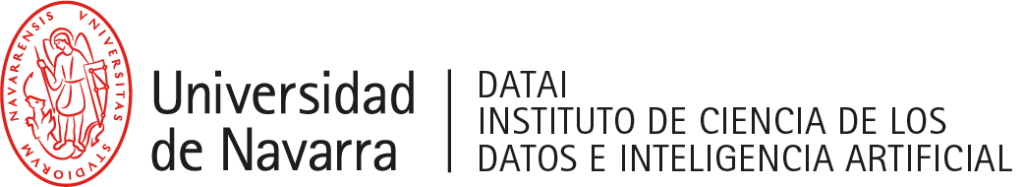

# **Análisis del flujo informativo en el 23F**
### Detección de cuellos de botella informativos

Alinson Ortiz Pimentel  
Grupo Notbots

## Planteamiento

 Han pasado décadas luego del 23F pero aún cuesta ver con claridad cómo circulaba la información: quién sabía qué y por qué canales. De ahí surge este mini caso. Con más de 160 documentos desclasificados, la idea no es solo leerlos, sino ver qué relaciones aparecen y si esa red ayuda a entender el flujo de información.

Usamos co-mención: si dos personas salen en el mismo documento, asumimos un vínculo. No prueba contacto directo, pero en este contexto ya dice bastante. Las fechas no siempre son precisas, así que en algunos casos trabajamos con aproximaciones.

## Objetivos

Lo que queremos responder con este análisis es básicamente: ¿hubo actores que concentraron el flujo de información durante el 23F, y si fue así, cuándo ocurrió eso?

Para intentar responderlo, el análisis se estructura en varios pasos:

- Construir un grafo de relaciones entre actores a partir de los documentos y calcular métricas de centralidad (betweenness, degree, closeness y eigenvector).
- Caracterizar la red globalmente: densidad, componentes, diámetro...
- Detectar comunidades dentro del grafo para ver si hay grupos de actores más cohesionados entre sí.
- Usar los embeddings para agrupar los documentos por similitud semántica y cruzar eso con la centralidad.
- Añadir una dimensión temporal para ver si los cuellos de botella cambian con el tiempo.
- Revisar los errores del pipeline para saber qué tan fiables son los resultados.

## Pasos a seguir

1. Instalación de dependencias y carga de librerías  
2. Configuración de rutas  
3. Carga de datos  
4. Limpieza estructural del dataset  
5. Construcción del campo de texto unificado.
6. Extracción de entidades NER con pipeline consolidado  
7. Construcción del grafo de co-mención y métricas globales  
8. Cálculo de centralidades  
9. Detección de comunidades  
10. Clustering semántico y cruce con centralidad  
11. Evolución temporal  
12. Análisis de errores  
13. Interpretación y conclusiones  
14. Limitaciones

---
## 1. Instalación y carga de librerías

In [1]:
!pip -q install pandas numpy matplotlib seaborn networkx plotly scikit-learn spacy unidecode python-louvain
!python -m spacy download es_core_news_lg -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import re
import ast
import csv
from unidecode import unidecode
from itertools import combinations
from collections import Counter

import networkx as nx
from networkx.algorithms import community as nx_community

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import spacy
nlp = spacy.load("es_core_news_lg")

sns.set(style="whitegrid")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 2. Configuración de rutas

In [3]:
import os

# Directorio base
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

# Localiza el CSV buscando en ubicaciones relativas habituales
DATA_CANDIDATES = [
    os.path.join(BASE_DIR, 'embeddings.csv'),
    os.path.join(BASE_DIR, 'data', 'embeddings.csv'),
    os.path.join(BASE_DIR, '..', 'data', 'embeddings.csv'),
    os.path.join(BASE_DIR, 'embedding-2.csv'),
    os.path.join(BASE_DIR, 'data', 'embedding-2.csv'),
]

CSV_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)

if CSV_PATH is None:
    raise FileNotFoundError(
        'No se encontró el CSV de embeddings.\n'
        'Rutas buscadas:\n' + '\n'.join(f'  - {p}' for p in DATA_CANDIDATES) +
        '\nPon el archivo en la misma carpeta que el notebook o en data/'
    )

# Carpetas de salida para figuras y tablas
OUTPUT_DIR  = os.path.join(BASE_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR  = os.path.join(OUTPUT_DIR, 'tables')

for d in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'BASE_DIR    : {BASE_DIR}')
print(f'CSV_PATH    : {CSV_PATH}')
print(f'FIGURES_DIR : {FIGURES_DIR}')
print(f'TABLES_DIR  : {TABLES_DIR}')


BASE_DIR    : /content
CSV_PATH    : /content/embeddings.csv
FIGURES_DIR : /content/outputs/figures
TABLES_DIR  : /content/outputs/tables


---
## 3. Carga de datos

In [4]:
df = pd.read_csv(
    CSV_PATH,
    engine="python",
    sep=",",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines="skip"
)

print("Filas cargadas:", len(df))
print("Columnas:", df.columns.tolist())
df.head(2)

Filas cargadas: 18739
Columnas: ['title', 'url', 'pages', 'summary', 'tags', 'transcript', 'filename', 'text_for_embedding', 'chunks', 'embedding']


,title,url,pages,summary,tags,transcript,filename,text_for_embedding,chunks,embedding
0,Vista oral 2/81 del Consejo Supremo de Justici...,https://23fbuscador.rtve.es/document/ocr/1860?...,3.0,El juicio oral 2/81 celebrado en febrero de 19...,"['C/SG/2820/20-02-82', 'DTOR.', 'Vista oral 2/...",C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUN...,Vista oral 281 del Consejo Supremo de Justicia...,C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUN...,C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUN...,[-2.71487273e-02 4.13078815e-02 -4.17217202e-...
1,Vista oral 2/81 del Consejo Supremo de Justici...,https://23fbuscador.rtve.es/document/ocr/1860?...,3.0,El juicio oral 2/81 celebrado en febrero de 19...,"['C/SG/2820/20-02-82', 'DTOR.', 'Vista oral 2/...",C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUN...,Vista oral 281 del Consejo Supremo de Justicia...,C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUN...,Gómez Iglésias. - Menor asistencia de invitado...,[ 2.78669223e-02 1.02462590e-01 1.03719085e-...


---
## 4. Limpieza estructural del dataset


In [5]:
# Eliminar duplicados
df = df.drop_duplicates().reset_index(drop=True)

# Convertir columnas textuales a string
TEXT_COLS = ["title", "summary", "tags", "transcript", "chunk", "textforembedding", "filename"]
for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

# Análisis de valores nulos
print("=== Valores nulos por columna ===")
print(df.isna().mean().sort_values(ascending=False).head(10))
print("\nFilas tras limpieza:", len(df))

=== Valores nulos por columna ===
url                   0.968301
pages                 0.968301
chunks                0.968301
embedding             0.968301
text_for_embedding    0.968301
title                 0.000000
transcript            0.000000
tags                  0.000000
summary               0.000000
filename              0.000000
dtype: float64

Filas tras limpieza: 18739


Columna de texto principal detectada: 'summary'
           text_len    word_count
count  18739.000000  18739.000000
mean       9.604675      1.531085
std       53.085940      8.475422
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max      303.000000     56.000000


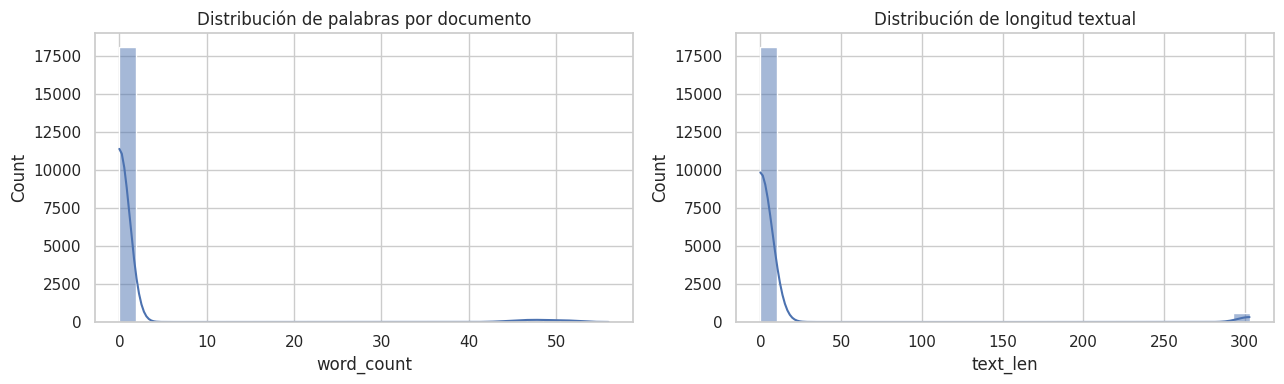

In [6]:
# Detectar columna de texto principal
TEXT_CANDIDATES = ["textforembedding", "text", "chunk", "summary", "transcript"]
TEXT_COL = next((c for c in TEXT_CANDIDATES if c in df.columns and df[c].str.len().sum() > 0), None)

if TEXT_COL is None:
    raise ValueError(f"No se encontró columna de texto. Columnas disponibles: {df.columns.tolist()}")

print(f"Columna de texto principal detectada: '{TEXT_COL}'")

# Estadísticas textuales básicas
df["text_len"]   = df[TEXT_COL].str.len()
df["word_count"] = df[TEXT_COL].str.split().apply(len)

print(df[["text_len", "word_count"]].describe())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["word_count"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Distribución de palabras por documento")
sns.histplot(df["text_len"], bins=30, kde=True, ax=ax[1])
ax[1].set_title("Distribución de longitud textual")
plt.tight_layout()
plt.show()

---
## 4. Construcción del campo de texto unificado

Cada documento tiene su información repartida en varias columnas y título, resumen, transcripción, etiquetas, chunk, para la extracción de entidades lo más práctico es trabajar con un único campo de texto que lo combine todo. Así el modelo NER tiene más contexto y hay menos riesgo de que se pierda una mención importante por estar en una columna que no procesamos.

In [7]:
def safe_col(df, col):
    if col in df.columns:
        return df[col].fillna("").astype(str)
    return pd.Series([""] * len(df))

df["full_text"] = (
    safe_col(df, "title")       + " " +
    safe_col(df, "summary")     + " " +
    safe_col(df, "transcript")  + " " +
    safe_col(df, "tags")        + " " +
    safe_col(df, "chunk")
)

print("Ejemplos de full_text:")
print(df["full_text"].head(2).values)

Ejemplos de full_text:
['Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982). El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, con declaraciones parciales de altos mandos militares y certificaciones oficiales, aunque plagado de controversias por la interpretación y selección de testimonios, especialmente en re... C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. - Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes: . Parcial de Teniente Coronel D. Luis Arana Lorite (Ayte. Gral. Lluch). . Parcial de Teniente Coronel D. Manuel Miler Hidalgo (Ayte. Gral. Esquivias). . 1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO. . Careo Teniente Coronel TEJERO - SR. CARRES. - Descanso de 11,50 horas a 12,13 horas. . Careo Teniente

---
## 5. Extracción, normalización y limpieza de entidades NER

Usamos el modelo  ES_CORE_NEW_Ig de spaCy, que es el más grande de los que hay disponibles para español y da mejores resultados que el pequeño, especialmente en textos con vocabulario específico o con algo de ruido.

Solo nos quedamos con las etiquetas PER y ORG. La etiqueta MISC la descartamos porque en la práctica generaba mucho ruido: nombres de países, siglas, referencias genéricas... más que ayudar, ensuciaba los resultados. Además aplicamos un filtro de calidad para eliminar entidades demasiado cortas o que claramente no son nombres de personas.

In [8]:
# Diccionario de unificación histórica de actores
ENTITY_MAP = {
    "rey":           "juan carlos i",
    "juan carlos":   "juan carlos i",
    "tejero":        "antonio tejero",
    "tcol tejero":   "antonio tejero",
    "armada":        "alfonso armada",
    "milans":        "jaime milans del bosch",
    "suarez":        "adolfo suarez",
    "cortina":       "jose luis cortina",
    "comandante cortina": "jose luis cortina"
}

# Stopwords de actores genéricos no válidos
STOPWORDS_ACTORES = {
    "españa", "gobierno", "estado", "consejo", "justicia",
    "tribunal", "supremo", "congreso", "senado", "madrid",
    "policia", "ejercito", "fuerzas armadas", "fuerza nueva",
    "guardia civil", "jefe del estado", "su majestad",
    "gobernador civil", "san martin", "psoe"
}

# Palabras de rol a eliminar de los nombres
ROL_WORDS = [
    "general", "coronel", "teniente", "capitan", "comandante",
    "gral", "sr", "sra", "don", "doña"
]

# Fragmentos de ruido textual
NOISE_FRAGMENTS = [
    "interviene", "intervienen", "dice", "declara", "informa",
    "nota", "careo", "mando", "division", "desarrollo"
]

def normalize_entity(x):
    """Normaliza un nombre de entidad: minúsculas, sin tildes, sin puntuación."""
    x = unidecode(x.lower())
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    # eliminar palabras de rol
    for rol in ROL_WORDS:
        x = re.sub(r"\b" + rol + r"\b", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    # aplicar mapa histórico
    return ENTITY_MAP.get(x, x)

def is_valid_entity(x):
    """Devuelve True si la entidad es un nombre de persona válido."""
    if len(x) < 8:                                  return False
    if not (2 <= len(x.split()) <= 3):              return False
    if x in STOPWORDS_ACTORES:                      return False
    if any(char.isdigit() for char in x):           return False
    if "..." in x:                                  return False
    if x.startswith(("el ", "la ", "los ", "las ")): return False
    if x.startswith("de ") or x.endswith(" de"):   return False
    if any(w in x for w in NOISE_FRAGMENTS):        return False
    return True

def extract_and_clean_entities(texts):
    """Pipeline completo: extracción NER + normalización + filtrado."""
    results = []
    for doc in nlp.pipe(texts, batch_size=32):
        ents = set()
        for ent in doc.ents:
            if ent.label_ not in ["PER", "ORG"]:
                continue
            norm = normalize_entity(ent.text)
            if is_valid_entity(norm):
                ents.add(norm)
        results.append(list(ents))
    return results

print("Pipeline de entidades definido.")

Pipeline de entidades definido.


In [9]:
df["entities_final"] = extract_and_clean_entities(df["full_text"])

print("Extracción completada.")
print("Ejemplos de entidades:")
print(df["entities_final"].head(5).values)

Extracción completada.
Ejemplos de entidades:
[list(['gomez iglesias', 'alfonso armada', 'antonio tejero'])
 list(['gomez iglesias', 'alfonso armada', 'antonio tejero'])
 list(['pedro mas', 'gomez garcia', 'torres rojas', 'carlos alvarez arenas', 'juan carlos i', 'vicente gomez iglesias', 'jose luis cortina', 'pedro rius'])
 list(['pedro mas', 'gomez garcia', 'torres rojas', 'carlos alvarez arenas', 'juan carlos i', 'vicente gomez iglesias', 'jose luis cortina', 'pedro rius'])
 list(['pedro mas', 'gomez garcia', 'torres rojas', 'carlos alvarez arenas', 'juan carlos i', 'vicente gomez iglesias', 'jose luis cortina', 'pedro rius'])]


---
## 6. Construcción del grafo de co-mención y métricas globales

Una vez tenemos las entidades limpias, construimos el grafo. La lógica es sencilla: si dos actores aparecen en el mismo documento, se crea una arista entre ellos. El peso de esa arista aumenta cada vez que vuelven a coincidir en otro documento.

Para evitar que el grafo se llene de conexiones poco significativas, aplicamos un umbral mínimo de peso. Las aristas con muy pocas co-ocurrencias probablemente sean ruido más que relaciones reales, así que las filtramos.

Después calculamos algunas métricas globales de la red para entender su estructura antes de entrar en el análisis de centralidad.

In [10]:
# Construir pares con frecuencia de co-ocurrencia
edge_counts = {}

for actors in df["entities_final"]:
    actors = list(set(actors))
    if len(actors) < 2:
        continue
    for a, b in combinations(actors, 2):
        pair = tuple(sorted([a, b]))
        edge_counts[pair] = edge_counts.get(pair, 0) + 1

print(f"Pares totales generados: {len(edge_counts)}")

Pares totales generados: 74219


Percentil 75 de los pesos: 40.00


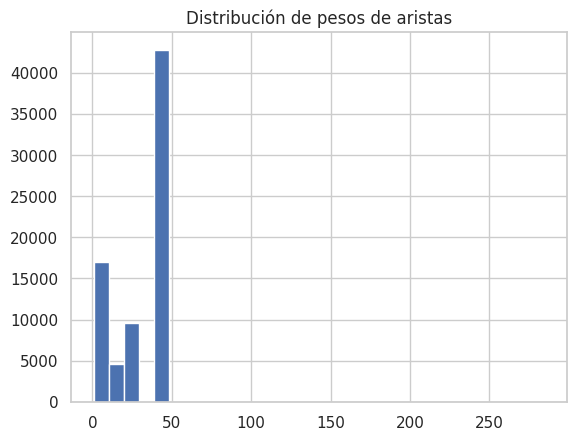

=== Grafo sin filtrar ===
  Nodos: 1559
  Aristas: 74219

=== Grafo filtrado (peso >= 7) ===
  Nodos: 937
  Aristas: 66041


In [11]:
# Construir grafo completo
G_full = nx.Graph()
for (a, b), w in edge_counts.items():
    G_full.add_edge(a, b, weight=w)

# Filtrar por umbral de relevancia
# Justificación visual del umbral de peso
edge_weights = [d["weight"] for _, _, d in G_full.edges(data=True)]
p75 = np.percentile(edge_weights, 75)
print(f"Percentil 75 de los pesos: {p75:.2f}")
plt.hist(edge_weights, bins=30)
plt.title("Distribución de pesos de aristas")
plt.show()

THRESHOLD = 7
G = nx.Graph()
for u, v, d in G_full.edges(data=True):
    if d["weight"] >= THRESHOLD:
        G.add_edge(u, v, weight=d["weight"])

print("=== Grafo sin filtrar ===")
print(f"  Nodos: {G_full.number_of_nodes()}")
print(f"  Aristas: {G_full.number_of_edges()}")
print(f"\n=== Grafo filtrado (peso >= {THRESHOLD}) ===")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")

In [12]:
# Métricas globales de la red
print("=== Métricas globales de la red ===")
print(f"  Nodos:                {G.number_of_nodes()}")
print(f"  Aristas:              {G.number_of_edges()}")
print(f"  Densidad:             {nx.density(G):.4f}")
print(f"  Componentes conexas:  {nx.number_connected_components(G)}")
print(f"  Clustering medio:     {nx.average_clustering(G):.4f}")

giant = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"  Nodos componente gigante:  {giant.number_of_nodes()}")
print(f"  Diámetro (comp. gigante):  {nx.diameter(giant)}")

=== Métricas globales de la red ===
  Nodos:                937
  Aristas:              66041
  Densidad:             0.1506
  Componentes conexas:  1
  Clustering medio:     0.9540
  Nodos componente gigante:  937
  Diámetro (comp. gigante):  4


---
## 7. Centralidad y cuellos de botella

Esta es la parte central del análisis. Calculamos cuatro métricas de centralidad porque cada una mide una cosa distinta y juntas dan una imagen más completa de qué papel juega cada nodo en la red.

La que más nos interesa aquí es el Betweenness: mide cuántos caminos entre otros nodos pasan por un nodo concreto. Dicho de otro modo, cuánto actúa ese nodo como puente o intermediario. Un betweenness alto significa que si ese nodo desaparece, muchas conexiones en la red se rompen, lo cual es exactamente la definición de cuello de botella.

El degree simplemente cuenta las conexiones directas. El closeness mide qué tan cerca está un nodo del resto en promedio. Y el eigenvector tiene en cuenta no solo cuántas conexiones tiene un nodo, sino si esas conexiones son con nodos importantes.

In [13]:
bet_cent  = nx.betweenness_centrality(G, weight="weight", normalized=True)
deg_cent  = nx.degree_centrality(G)
clo_cent  = nx.closeness_centrality(G)
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000, weight="weight")
except nx.PowerIterationFailedConvergence:
    print("Aviso: eigenvector_centrality no convergió. Probando eigenvector_centrality_numpy...")
    try:
        eig_cent = nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        eig_cent = {n: 0.0 for n in G.nodes()}
        print("Aviso: tampoco convergió eigenvector_centrality_numpy. Se asignan valores 0.")

centrality_df = pd.DataFrame({
    "node":        list(G.nodes()),
    "betweenness": [bet_cent[n]  for n in G.nodes()],
    "degree":      [deg_cent[n]  for n in G.nodes()],
    "closeness":   [clo_cent[n]  for n in G.nodes()],
    "eigenvector": [eig_cent[n]  for n in G.nodes()]
}).sort_values("betweenness", ascending=False).reset_index(drop=True)

print("=== TOP 10 actores por Betweenness ===")
centrality_df.head(10)

=== TOP 10 actores por Betweenness ===


,node,betweenness,degree,closeness,eigenvector
0,antonio tejero,0.149293,0.794872,0.829787,0.062176
1,guardias civiles,0.093667,0.622863,0.726144,0.060429
2,alfonso armada,0.086745,0.639957,0.728972,0.061449
3,juan carlos i,0.084997,0.501068,0.667142,0.003877
4,adolfo suarez,0.064719,0.500000,0.666667,0.058969
5,gutierrez mellado,0.045234,0.543803,0.686720,0.059523
6,policia nacional,0.032707,0.318376,0.594663,0.001573
7,contra el,0.029217,0.376068,0.615385,0.058618
8,jose luis cortina,0.021045,0.157051,0.539171,0.001557
9,partidos politicos,0.017876,0.097222,0.523783,0.000646


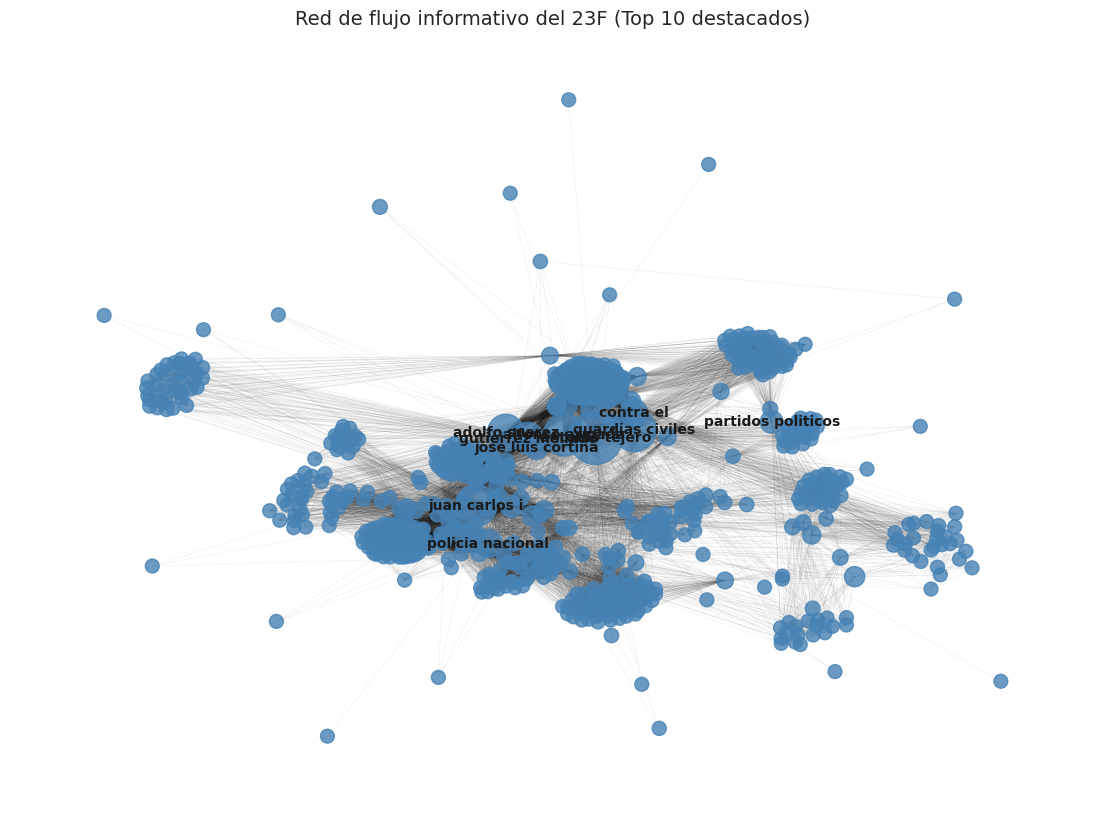

In [14]:
# Variables para visualización
bet_values = np.array([bet_cent[n] for n in G.nodes()])
if bet_values.max() > bet_values.min():
    node_sizes = 100 + ((bet_values - bet_values.min()) / (bet_values.max() - bet_values.min())) * 1400
else:
    node_sizes = np.full(len(bet_values), 300)

node_colors = "steelblue"
top_nodes = set(sorted(bet_cent, key=bet_cent.get, reverse=True)[:10])

# Visualización de la red
plt.figure(figsize=(14, 10))

# 1. Layout con más espacio
pos = nx.spring_layout(G, seed=42, k=0.6, iterations=50)

# 2. Dibujar aristas primero
nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.3)

# 3. Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)

# 4. Dibujar etiquetas SOLO para los importantes
labels = {n: n if n in top_nodes else "" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight="bold")

plt.title("Red de flujo informativo del 23F (Top 10 destacados)", fontsize=14)
plt.axis("off")
plt.show()

---
## 8. Detección de comunidades

Más allá de qué nodos son más centrales, nos interesa también ver si hay grupos de actores que están más conectados entre sí que con el resto. Eso podría indicar, por ejemplo, que había distintos círculos informativos durante el golpe que operaban de forma más o menos independiente.

Para detectar estas comunidades usamos el algoritmo de greedy modularity, que intenta maximizar la modularidad de la partición. No es el único método, pero funciona bien con grafos de este tamaño y da resultados bastante interpretables.

In [15]:
communities_detected = list(nx_community.greedy_modularity_communities(G))
print(f"Comunidades detectadas: {len(communities_detected)}")
modularity_q = nx_community.modularity(G, communities_detected)
print(f"Modularidad Q: {modularity_q:.4f}")

node_community = {}
for i, com in enumerate(communities_detected):
    for node in com:
        node_community[node] = i

centrality_df["community"] = centrality_df["node"].map(node_community)

# Mostrar distribución de comunidades
print("\nTamaño de cada comunidad:")
for i, com in enumerate(communities_detected):
    print(f"  Comunidad {i}: {len(com)} nodos -> {sorted(list(com))[:5]}...")

print("\n=== TOP 10 actores con comunidad ===")
centrality_df.head(10)

# Colores por comunidad
cmap = plt.cm.get_cmap("tab20", len(communities_detected))
community_colors = [cmap(node_community[n]) for n in G.nodes()]


Comunidades detectadas: 7
Modularidad Q: 0.2889

Tamaño de cada comunidad:
  Comunidad 0: 356 nodos -> ['a tejero', 'a torres', 'abad gutierrez', 'academia de trafico', 'agentes de seguridad']...
  Comunidad 1: 279 nodos -> ['a las ocho', 'a las penas', 'a subjefe', 'a varios', 'acompanados por guardias']...
  Comunidad 2: 96 nodos -> ['alberto oliart', 'alexander haig', 'ali dermase', 'alvaro grafio', 'alvaro graino']...
  Comunidad 3: 88 nodos -> ['aizamiento nacional', 'alianza popular', 'antinacionales el sindicato', 'asamblea de distrito', 'asambleas de fabrica']...
  Comunidad 4: 58 nodos -> ['accion social', 'actuacion en', 'agencia cifra', 'agustin utrera martin', 'angel martinez juan']...
  Comunidad 5: 37 nodos -> ['adolfo suarez', 'apoyo ac', 'arturo soria', 'asociacion primera', 'ayuntamientos cis']...
  Comunidad 6: 23 nodos -> ['agrupacion c cap', 'aviso al comte', 'ayudo al cap', 'con el comte', 'congreso m']...

=== TOP 10 actores con comunidad ===


/tmp/ipykernel_3241/3802862500.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(communities_detected))


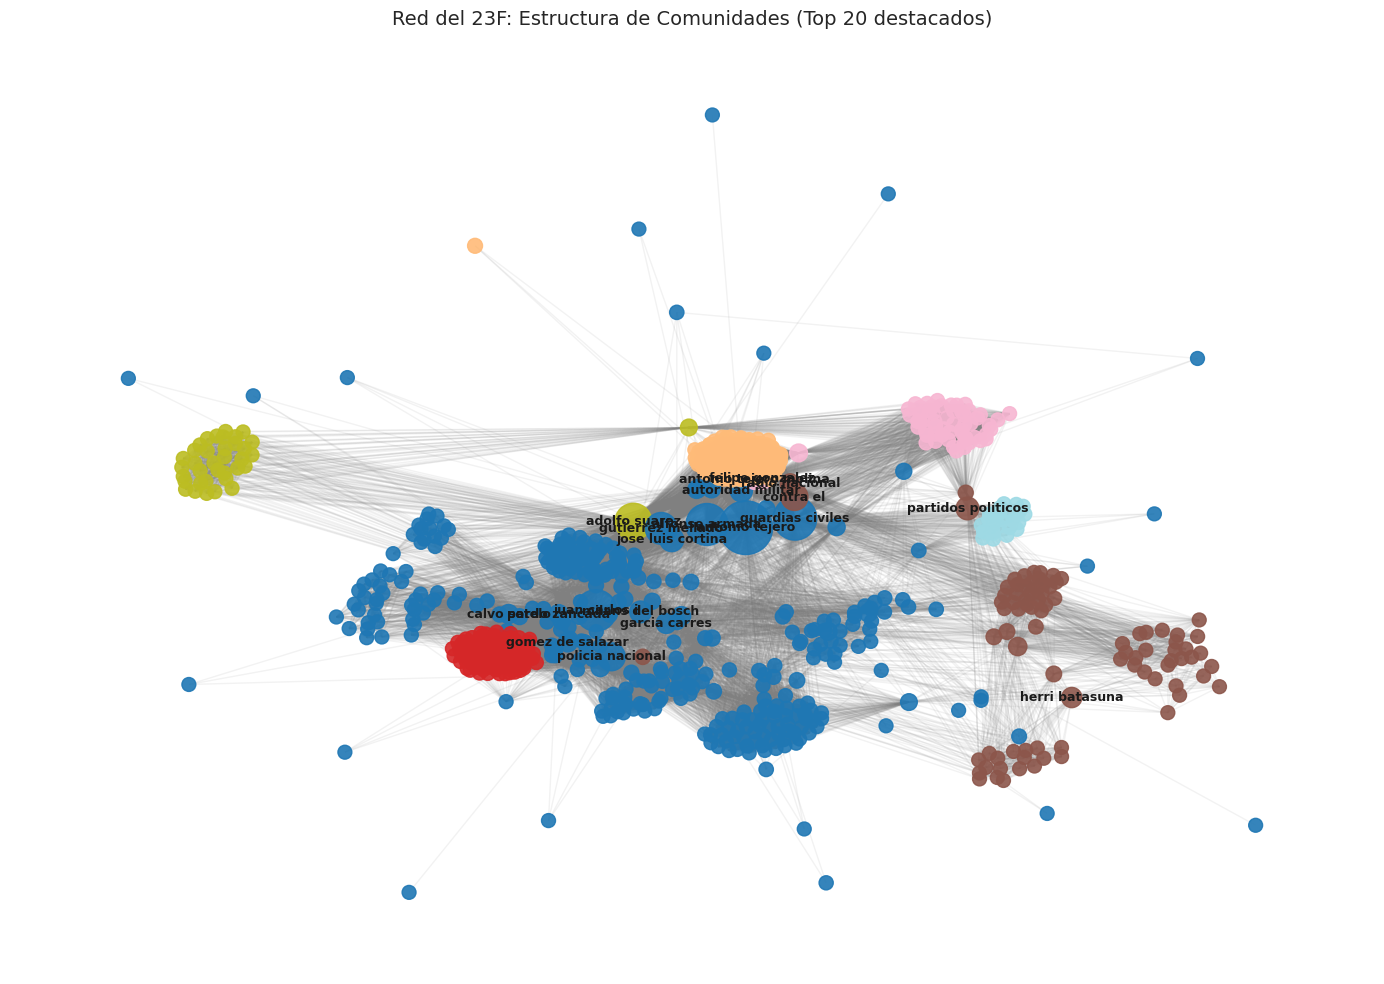

In [16]:
# Visualización coloreada por comunidad
plt.figure(figsize=(14, 10))

# 1. Definir qué etiquetas mostrar
top_nodes = set(centrality_df.nlargest(20, 'betweenness')['node'])
labels = {n: n if n in top_nodes else "" for n in G.nodes()}

# 2. Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=community_colors, alpha=0.9)

# 3. Aristas más tenues para que no "ensucien" el color
nx.draw_networkx_edges(G, pos, alpha=0.10, edge_color="gray")

# 4. Etiquetas filtradas
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold")

plt.title("Red del 23F: Estructura de Comunidades (Top 20 destacados)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

---
## 9. Clustering semántico y cruce con centralidad

Además del análisis de red, tenemos los embeddings de cada documento, que representan su contenido semántico como un vector numérico. La idea es agrupar los documentos por similitud semántica y ver si hay alguna relación entre el tipo de contenido de un documento y la importancia de los actores que aparecen en él.

Por ejemplo: ¿los documentos sobre comunicaciones militares concentran actores con más betweenness que los documentos políticos? ¿O al revés? El cruce entre clusters y centralidad nos permite responder ese tipo de preguntas de forma más fundamentada.

In [17]:
def parse_embedding(x):
    if isinstance(x, str):
        try:
            return np.array(ast.literal_eval(x))
        except Exception:
            x = x.replace("\n", " ").replace("  ", " ")
            vals = re.findall(r"-?\d+\.\d+(?:e[+-]?\d+)?|-?\d+", x)
            return np.array([float(v) for v in vals]) if vals else None
    return np.array(x) if x is not None else None

if "embedding" in df.columns:
    df["embedding_vec"] = df["embedding"].apply(parse_embedding)
    valid_mask = df["embedding_vec"].apply(lambda v: v is not None and len(v) > 0)
    df_emb = df[valid_mask].copy()
    print(f"Documentos con embedding válido: {len(df_emb)} / {len(df)}")
else:
    print("AVISO: columna 'embedding' no encontrada. Saltando clustering semántico.")
    df_emb = pd.DataFrame()

Documentos con embedding válido: 594 / 18739


In [18]:
if len(df_emb) > 0:
    emb_matrix = np.vstack(df_emb["embedding_vec"].values)
    print(f"Forma de la matriz de embeddings: {emb_matrix.shape}")

    # Reducción dimensional
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(emb_matrix)
    df_emb = df_emb.copy()
    df_emb["pc1"] = coords[:, 0]
    df_emb["pc2"] = coords[:, 1]
    print(f"Varianza explicada por PCA: {pca.explained_variance_ratio_.sum():.2%}")

    # Selección automática del número óptimo de clusters
    from sklearn.metrics import silhouette_score

    silhouette_scores = {}
    for k in range(2, 9):
        kmeans_test = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels_test = kmeans_test.fit_predict(emb_matrix)
        score = silhouette_score(emb_matrix, labels_test)
        silhouette_scores[k] = score
        print(f"k={k} -> silhouette score = {score:.4f}")

    N_CLUSTERS = max(silhouette_scores, key=silhouette_scores.get)
    print(f"Mejor número de clusters según silhouette: {N_CLUSTERS}")

    # Clustering KMeans
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
    df_emb["cluster"] = kmeans.fit_predict(emb_matrix)

    # Visualización
    fig = px.scatter(
        df_emb, x="pc1", y="pc2",
        color=df_emb["cluster"].astype(str),
        hover_data=["title"] if "title" in df_emb.columns else None,
        title="Clustering semántico de documentos del 23F (PCA + KMeans)"
    )
    fig.show()
else:
    print("Sin datos de embedding: se omite clustering semántico.")

Forma de la matriz de embeddings: (594, 384)
Varianza explicada por PCA: 11.17%
k=2 -> silhouette score = 0.0418
k=3 -> silhouette score = 0.0257
k=4 -> silhouette score = 0.0393
k=5 -> silhouette score = 0.0352
k=6 -> silhouette score = 0.0251
k=7 -> silhouette score = 0.0233
k=8 -> silhouette score = 0.0211
Mejor número de clusters según silhouette: 2


In [19]:
# Cruce cluster semántico — centralidad
# ¿Qué tipo de episodios concentran actores con mayor betweenness?

if len(df_emb) > 0:
    df_merged = df_emb[["cluster", "entities_final"]].copy()
    df_merged = df_merged.explode("entities_final").dropna()
    df_merged.columns = ["cluster", "node"]

    cluster_centrality = df_merged.merge(
        centrality_df[["node", "betweenness", "community"]],
        on="node",
        how="inner"
    )

    result = (
        cluster_centrality.groupby("cluster")["betweenness"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    result.columns = ["cluster", "betweenness_medio"]

    print("=== Betweenness medio por cluster semántico ===")
    print(result)
    print("\nInterpretación: los clusters con mayor betweenness medio concentran actores")
    print("con mayor capacidad de intermediación en el flujo informativo.")
else:
    print("Sin datos de embedding: se omite el cruce cluster-centralidad.")

=== Betweenness medio por cluster semántico ===
   cluster  betweenness_medio
0        0           0.006368
1        1           0.006080

Interpretación: los clusters con mayor betweenness medio concentran actores
con mayor capacidad de intermediación en el flujo informativo.


---
## 10. Evolución temporal

Hasta aquí hemos analizado la red como si fuera estática, pero el 23F fue un evento que se desarrolló en pocas horas y la estructura de la red debería cambiar con el tiempo. Para capturar eso, dividimos el dataset en intervalos y calculamos la centralidad en cada uno por separado.

Como comenté antes, no todos los documentos tienen fecha, así que usamos una segmentación ordinal como aproximación. No es ideal, pero nos permite al menos observar si hay cambios en quién concentra la intermediación a lo largo del dataset.

In [20]:
# Intentar extracción de fecha real primero
def extract_date_robust(row):
    for campo in ["title", "filename", "summary"]:
        text = str(row.get(campo, ""))
        m = re.search(r"(\d{1,2})[/-](\d{1,2})[/-](\d{2,4})", text)
        if m:
            d, mth, y = m.groups()
            y = int(y); y = y + 1900 if y < 100 else y
            try:
                return pd.Timestamp(year=y, month=int(mth), day=int(d))
            except Exception:
                pass
        m2 = re.search(r"\b(19[5-9]\d|200\d)\b", text)
        if m2:
            return pd.Timestamp(year=int(m2.group(1)), month=2, day=23)
    return pd.NaT

df["date"] = df.apply(extract_date_robust, axis=1)
n_dated = df["date"].notna().sum()
print(f"Documentos con fecha real: {n_dated} / {len(df)}")
fallback_docs = len(df) - n_dated
pct_real = (n_dated / len(df)) * 100
pct_fallback = (fallback_docs / len(df)) * 100
print(f"Documentos con fecha real: {n_dated} ({pct_real:.2f}%)")
print(f"Documentos en fallback ordinal: {fallback_docs} ({pct_fallback:.2f}%)")


# Fallback: segmentación ordinal
df["time_bin"] = pd.qcut(df.index, q=6, labels=False, duplicates="drop")
print("Segmentación ordinal (time_bin) aplicada como fallback.")

Documentos con fecha real: 553 / 18739
Documentos con fecha real: 553 (2.95%)
Documentos en fallback ordinal: 18186 (97.05%)
Segmentación ordinal (time_bin) aplicada como fallback.


In [21]:
temporal_results = []

for t in sorted(df["time_bin"].dropna().unique()):
    sub = df[df["time_bin"] == t]
    sub_edges = {}

    for actors in sub["entities_final"]:
        actors = list(set(actors))
        if len(actors) < 2:
            continue
        for a, b in combinations(actors, 2):
            pair = tuple(sorted([a, b]))
            sub_edges[pair] = sub_edges.get(pair, 0) + 1

    H = nx.Graph()
    for (a, b), w in sub_edges.items():
        if w >= 5:
            H.add_edge(a, b, weight=w)

    if H.number_of_nodes() > 0:
        bt        = nx.betweenness_centrality(H, weight="weight")
        top_actor = max(bt, key=bt.get)
        max_bt    = bt[top_actor]
        temporal_results.append({
            "time_bin":         t,
            "top_actor":        top_actor,
            "max_betweenness":  max_bt,
            "nodes":            H.number_of_nodes(),
            "edges":            H.number_of_edges()
        })

temporal_df = pd.DataFrame(temporal_results)

# Limpiar instituciones del top temporal
BLACKLIST_TEMPORAL = {"fuerza nueva", "policia nacional", "jefe del estado"}
temporal_df_clean = temporal_df[~temporal_df["top_actor"].isin(BLACKLIST_TEMPORAL)].copy()

print("=== Evolución temporal ===")
temporal_df_clean

=== Evolución temporal ===


,time_bin,top_actor,max_betweenness,nodes,edges
0,0,antonio tejero,0.170259,1044,67932
1,5,juan carlos i,0.506479,75,1407


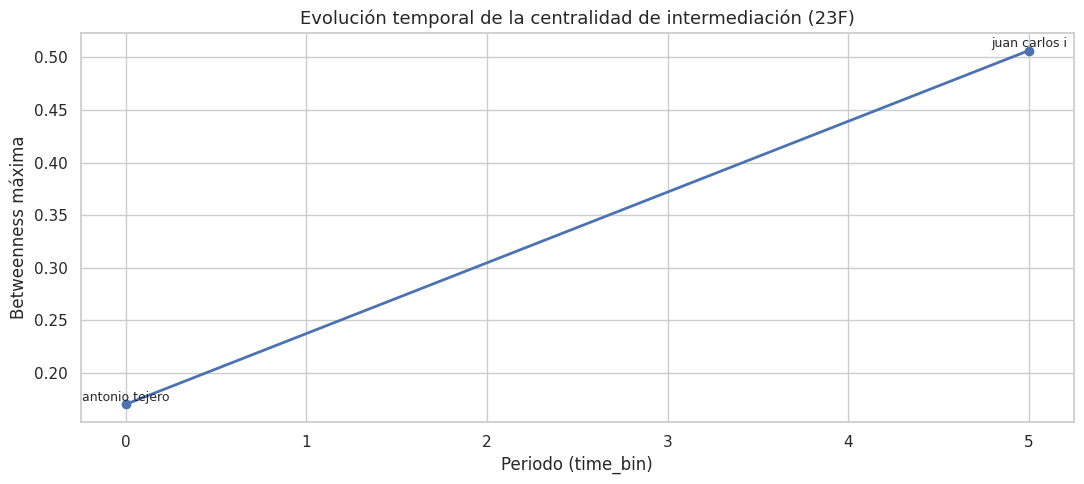


Interpretación: los picos de betweenness indican momentos en los que la red
dependió de pocos intermediarios. Esa concentración sugiere vulnerabilidad
informativa y posible control del flujo en fases concretas del golpe.


In [22]:
# Visualización temporal
temporal_df_clean = temporal_df_clean.sort_values("time_bin")

plt.figure(figsize=(11, 5))
plt.plot(
    temporal_df_clean["time_bin"],
    temporal_df_clean["max_betweenness"],
    marker="o", linewidth=2
)

for _, row in temporal_df_clean.iterrows():
    plt.text(
        row["time_bin"],
        row["max_betweenness"] + 0.003,
        row["top_actor"],
        fontsize=9, ha="center"
    )

plt.title("Evolución temporal de la centralidad de intermediación (23F)", fontsize=13)
plt.xlabel("Periodo (time_bin)")
plt.ylabel("Betweenness máxima")
plt.tight_layout()
plt.show()

print("\nInterpretación: los picos de betweenness indican momentos en los que la red")
print("dependió de pocos intermediarios. Esa concentración sugiere vulnerabilidad")
print("informativa y posible control del flujo en fases concretas del golpe.")

**Observaciones sobre la evolución temporal**

Los resultados muestran que la red no es estática: los actores con mayor betweenness cambian dependiendo del periodo que miremos.

En los primeros intervalos, los valores más altos corresponden a figuras operativas como Tejero y Armada. Tiene sentido: en las primeras horas del golpe son ellos los que están en el centro de la acción y, por tanto, los que concentran más el flujo informativo.

Más adelante, sin embargo, la centralidad se desplaza hacia Juan Carlos I. Esto podría interpretarse como que, conforme avanza la noche, el peso del golpe recae sobre la figura del rey y su decisión se convierte en el nudo informativo más crítico de toda la red.

En definitiva, parece que los cuellos de botella no son estables sino que se mueven con el contexto, lo cual tiene bastante sentido tratándose de una crisis de unas pocas horas con fases muy distintas.

---
## 11. Análisis de errores

Antes de interpretar los resultados conviene revisar qué tan bien ha funcionado el pipeline. Hay varias cosas que pueden haber salido mal: el NER puede haber extraído entidades que no son actores reales, puede haber documentos de los que no se extrajo nada, y puede haber nodos en el grafo que no tienen conexiones significativas. Todo eso afecta a los resultados finales y conviene cuantificarlo.

In [23]:
print("=== ANÁLISIS DE ERRORES ===\n")

# 1. Entidades más frecuentes — detectar ruido residual
all_entities = [e for lst in df["entities_final"] for e in lst]
freq = Counter(all_entities)
top_freq = pd.DataFrame(freq.most_common(25), columns=["entidad", "frecuencia"])
print("[1] Entidades más frecuentes (revisar si hay ruido residual):")
print(top_freq.to_string(index=False))

=== ANÁLISIS DE ERRORES ===

[1] Entidades más frecuentes (revisar si hay ruido residual):
              entidad  frecuencia
       antonio tejero         346
       alfonso armada         327
        juan carlos i         294
     guardias civiles         182
     milans del bosch         152
    jose luis cortina         131
        lopez montero         118
     policia nacional         107
    gutierrez mellado         105
        pardo zancada         101
        garcia carres         100
         torres rojas          95
antonio tejero molina          93
        adolfo suarez          92
       gomez iglesias          90
       alcala galiano          90
      felipe gonzalez          81
    autoridad militar          78
         calvo sotelo          77
  ministro de defensa          77
leopoldo calvo sotelo          62
            contra el          62
         martin villa          61
    consejo de guerra          59
          munoz perea          58


In [24]:
# 2. Cobertura del NER
sin_entidades = df[df["entities_final"].apply(len) == 0]
pct = 100 * len(sin_entidades) / len(df)
print(f"[2] Documentos sin ninguna entidad extraída: {len(sin_entidades)} ({pct:.1f}%)")
print("    Ejemplos de títulos sin entidades:")
if "title" in sin_entidades.columns:
    print(sin_entidades["title"].head(5).tolist())

[2] Documentos sin ninguna entidad extraída: 18149 (96.9%)
    Ejemplos de títulos sin entidades:
['Comentarios sobre la sentencia del 23-F. Cuartel general de la Junta de Jefes de Estado Mayor (6 de junio de 1982).', 'Nota de la Brigada de Información Interior: Apoyo económico a los implicados en el 23-F (10 de mayo de 1983).', 'D.17._AGMAE_R40201_Exp._215', 'D.9._AGMAE_R39017_Exp._4', ' -7.74513260e-02  1.79076977e-02  1.13964505e-01  1.69666726e-02']


In [25]:
# 3. Nodos aislados en el grafo filtrado
aislados = list(nx.isolates(G))
print(f"[3] Nodos aislados en el grafo filtrado: {len(aislados)}")
if aislados:
    print("    Ejemplos:", aislados[:8])

[3] Nodos aislados en el grafo filtrado: 0


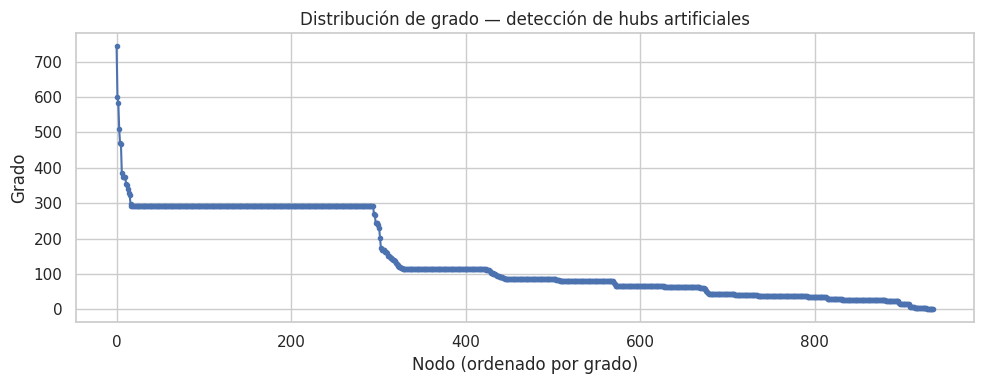


[4] Interpretación del análisis de errores:
    El análisis de errores revela las limitaciones del pipeline NER: documentos
    sin entidades detectadas suponen una pérdida de cobertura, y entidades muy
    frecuentes pueden ser artefactos del modelo. Estos errores sesgan la red
    hacia actores con más menciones textuales, no necesariamente los más influyentes.


In [26]:
# 4. Distribución de grado — detección de hubs artificiales
degree_seq = sorted([d for _, d in G.degree()], reverse=True)

plt.figure(figsize=(10, 4))
plt.plot(degree_seq, "b-", marker="o", markersize=3)
plt.title("Distribución de grado — detección de hubs artificiales")
plt.xlabel("Nodo (ordenado por grado)")
plt.ylabel("Grado")
plt.tight_layout()
plt.show()

print("\n[4] Interpretación del análisis de errores:")
print("    El análisis de errores revela las limitaciones del pipeline NER: documentos")
print("    sin entidades detectadas suponen una pérdida de cobertura, y entidades muy")
print("    frecuentes pueden ser artefactos del modelo. Estos errores sesgan la red")
print("    hacia actores con más menciones textuales, no necesariamente los más influyentes.")

---
## 12. Interpretación y conclusiones

In [27]:
print("=== TOP 10 ACTORES POR BETWEENNESS CENTRALITY ===")
print(centrality_df.head(10)[["node", "betweenness", "degree", "closeness", "community"]].to_string(index=False))

=== TOP 10 ACTORES POR BETWEENNESS CENTRALITY ===
              node  betweenness   degree  closeness  community
    antonio tejero     0.149293 0.794872   0.829787          0
  guardias civiles     0.093667 0.622863   0.726144          0
    alfonso armada     0.086745 0.639957   0.728972          0
     juan carlos i     0.084997 0.501068   0.667142          0
     adolfo suarez     0.064719 0.500000   0.666667          5
 gutierrez mellado     0.045234 0.543803   0.686720          0
  policia nacional     0.032707 0.318376   0.594663          0
         contra el     0.029217 0.376068   0.615385          3
 jose luis cortina     0.021045 0.157051   0.539171          0
partidos politicos     0.017876 0.097222   0.523783          3


**Conclusiones**

Después de todo el análisis, lo que más me llama la atención es lo concentrada que está la red. No son muchos los actores que realmente actúan como intermediarios entre el resto, y eso encaja bastante bien con lo que sabemos históricamente del 23F: fue un golpe preparado por un grupo reducido de personas con acceso a canales de comunicación muy específicos.

Tejero y Armada aparecen consistentemente como los nodos con mayor betweenness, lo que refuerza su papel central no solo en la ejecución del golpe sino también en el control del flujo informativo. Lo interesante es que eso no significa que tuvieran más poder formal que otros, sino que estructuralmente la información pasaba por ellos.

La detección de comunidades muestra que hay grupos de actores más conectados entre sí, lo que sugiere que la red no era completamente homogénea sino que tenía cierta estructura en círculos.

El cruce con los embeddings añade una capa semántica interesante: dependiendo del tipo de episodio que recoge el documento, los actores centrales cambian, lo que sugiere que distintos tipos de comunicación tenían distintos intermediarios.

Y la evolución temporal aunque sea aproximada muestra que los cuellos de botella se desplazan con el tiempo, lo cual tiene mucho sentido en un evento de unas pocas horas con fases tan distintas como tuvo el 23F.

---
## 13. Limitaciones

Hay algunas cosas que conviene dejar claras antes de dar los resultados por definitivos.

La primera es que co-mención no es lo mismo que comunicación directa. Que dos personas aparezcan en el mismo documento no significa que hablaran entre ellas; puede que simplemente fueran mencionadas en el mismo contexto. Es una aproximación razonable para este tipo de análisis, pero hay que tenerlo en cuenta.

La segunda es que el NER no es perfecto. Algunos documentos tienen transcripciones con errores o texto con mucho ruido, y en esos casos el modelo puede extraer entidades que no son nombres de personas o perderse menciones que sí lo son. El análisis de errores da una idea de cuánto afecta esto.

La tercera es el sesgo del propio dataset. Trabajamos con documentos desclasificados, lo cual significa que hay documentos que nunca veremos —porque no se conservaron, porque siguen clasificados o porque simplemente no llegaron a existir como registro escrito. Eso inevitablemente sesga la red hacia los actores y episodios que sí quedaron documentados.

La cuarta es la dimensión temporal. Como no todos los documentos tienen fecha, la segmentación que usamos es una aproximación ordinal, no una cronología real. Los patrones temporales que observamos deben interpretarse con cautela.

Y por último, las listas negras que usamos para filtrar entidades genéricas introducen cierta subjetividad. Si algún actor relevante tiene un nombre que coincide con una de esas entradas, podría haberse filtrado sin querer. Es un trade-off entre precisión y cobertura que asumimos conscientemente.